# Wakeel: A Self-Healing, Frequency-Aware Configuration Engine for Open-Source RTL-to-GDSII Flows

**IEEE SSCS Open-Source Ecosystem — Code-a-Chip Travel Grant, ISSCC 2027**

**Author:** Rishi Kesavan— Mahendra College of Engineering, Salem, Tamil Nadu, India (B.E. ECE)
**License:** Apache License 2.0 (see `LICENSE` in this folder — matches OpenLane's own license and is compatible with ORFS's BSD-3-Clause license)
**Open-source tools used:** [OpenLane](https://github.com/The-OpenROAD-Project/OpenLane) (SkyWater 130nm / `sky130A`) and [OpenROAD-flow-scripts (ORFS)](https://github.com/The-OpenROAD-Project/OpenROAD-flow-scripts) (ASAP7 7nm) — both fully open-source RTL-to-GDSII flows built on [OpenROAD](https://theopenroad.org/) and [Yosys](https://github.com/YosysHQ/yosys)
**Category:** Educational flow built with open-source tools and PDKs / exploration of open-source PDK-driven design-space behavior

---

## Abstract

Open-source RTL-to-GDSII flows (OpenLane, ORFS) give anyone access to real silicon compilation — but using them well still requires knowing, by hand, things like "which synthesis strategy fights a tight clock target" or "what does this three-line DRC error actually mean for my config." That tacit knowledge is exactly the kind of barrier that keeps open-source chip design from being as accessible as it could be.

**Wakeel** is an agentic orchestration layer I built on top of OpenLane/ORFS that encodes some of that tacit knowledge as *executable, inspectable logic* instead of leaving it in an engineer's head:

1. A **schema-driven configuration engine** that generates valid OpenLane/ORFS configs from a single source of truth, so adding support for a new tool parameter is a one-line JSON edit, never a code change.
2. A **frequency-aware physical profile** that automatically escalates synthesis/resizer aggressiveness as a function of target clock frequency and PDK, instead of relying on one static default that's wrong at either extreme.
3. A **self-healing knowledge base** that reads a real failure (a DRC/LVS violation, a timing miss) and proposes a *typed, explained* configuration correction — grounded in the actual parameter schema, not free text.

This notebook demonstrates all three pieces running against real code from the project (not a toy reimplementation — the exact modules Wakeel's orchestrator uses in production), plus a section for real OpenLane/ORFS hardware-run results generated locally (Docker + PDK are required for that part and aren't available in a hosted notebook environment — see the Reproducibility section for exactly how to add your own).

Full project (including the live orchestrator, web dashboard, and test suite this notebook's logic is drawn from): **https://github.com/Rishikesavan0129/wakeel**


## Setup

This notebook clones the actual Wakeel repository and checks out a **fixed
commit** (not `main`) — so the code that ran to produce every result below
is permanently pinned, and stays reproducible even after the project keeps
being developed. Only the standard library is required to import the
package used here (`wakeel.config_generator`, `wakeel.knowledge_base`,
`wakeel.physical_profile`) — no FastAPI/WebSocket/Docker dependency, which
is what makes this runnable in Colab with zero extra installs.

**Repository:** https://github.com/Rishikesavan0129/wakeel


In [1]:
# Pinned commit -- update this to whatever commit you want this notebook's
# results frozen against (get it with `git log -1 --format=%H` in your repo).
WAKEEL_COMMIT = "edeeab4147ab054a189be4a18b63aea70369424b"
WAKEEL_REPO_URL = "https://github.com/Rishikesavan0129/wakeel.git"

import sys, os, json, subprocess

if not os.path.isdir("wakeel_repo_checkout"):
    subprocess.run(["git", "clone", WAKEEL_REPO_URL, "wakeel_repo_checkout"], check=True)
subprocess.run(["git", "-C", "wakeel_repo_checkout", "checkout", WAKEEL_COMMIT], check=True)

sys.path.insert(0, os.path.abspath("wakeel_repo_checkout"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from wakeel.config_generator import ConfigSchema, build_params, render
from wakeel.knowledge_base import KnowledgeBase
from wakeel import physical_profile

schema = ConfigSchema()
kb = KnowledgeBase(schema)

print(f"Checked out commit: {WAKEEL_COMMIT[:10]}")
print(f"Schema loaded: {len(schema.for_tool('openlane'))} OpenLane params, "
      f"{len(schema.for_tool('orfs'))} ORFS params.")
print(f"Knowledge base loaded: {kb.stats()['total_rules']} self-heal rules "
      f"across {len(kb.stats()['by_category'])} categories.")


Checked out commit: edeeab4147
Schema loaded: 92 OpenLane params, 20 ORFS params.
Knowledge base loaded: 51 self-heal rules across 16 categories.


## Part 1 — Schema-driven configuration generation

Every OpenLane/ORFS parameter Wakeel knows about lives in one JSON file (`config_schema.json`), not scattered across Python code. `build_params()` starts from that schema's defaults for a given tool, then layers user/design-specific overrides on top — and every override is type-coerced against the schema (so a config re-seeded from an existing file's text doesn't silently flip a disabled boolean flag to enabled, a real bug this coercion step exists to prevent).

Below, we generate a real `config.mk` for an ORFS/ASAP7 run from scratch.


In [2]:
overrides = {
    "core_util": 45,          # resolved via an advisory alias -> FP_CORE_UTIL / CORE_UTILIZATION
    "CLOCK_PERIOD": 1000,     # 1 GHz target, in ps
}

params = build_params("orfs", schema, overrides)
config_text = render("orfs", params, schema)
print(config_text)


# ===== WAKEEL GENERATED ORFS CONFIG.MK (schema-driven, dynamically expandable) =====
export CLOCK_PERIOD = 1000.0
export CLOCK_PORT = clk
export CORE_ASPECT_RATIO = 1.0
export CORE_UTILIZATION = 45.0
export DETAILED_ROUTE_END_ITERATION = 64
export HOLD_SLACK_MARGIN = 0.1
export MACRO_PLACE_CHANNEL = 10 10
export MACRO_PLACE_HALO = 5 5
export PLACE_DENSITY = 0.45
export PLACE_SITE = asap7sc7p5t_27_R
export PLATFORM = asap7
export SYNTH_FLAT_TOP = 0
export SYNTH_MAX_FANOUT = 20
export VERILATOR_RELAX = 1



## Part 2 — Frequency-aware physical profiling

A single static synthesis strategy can't be right across the whole frequency range a design might target: area-optimized synthesis with resizer optimizations off is a reasonable default at a relaxed clock, and actively wrong (in the "will fail static timing analysis" sense, not just "sub-optimal") at an aggressive one.

`physical_profile.apply()` classifies how aggressive a requested frequency is *relative to the target node* and escalates synthesis strategy + resizer settings accordingly. This is a genuinely open design-space question — the frequency bands below are rule-of-thumb guardrails I calibrated by hand, not verified silicon physics, and the module's own docstring says so explicitly (see `wakeel_lib/physical_profile.py`). They're deliberately isolated in one small dict specifically so they're easy to recalibrate against real timing-closure data as it's gathered — which is exactly what the "real hardware run" section further down starts doing.

The sweep below shows the tier transition across roughly three decades of frequency, for both PDKs Wakeel targets.


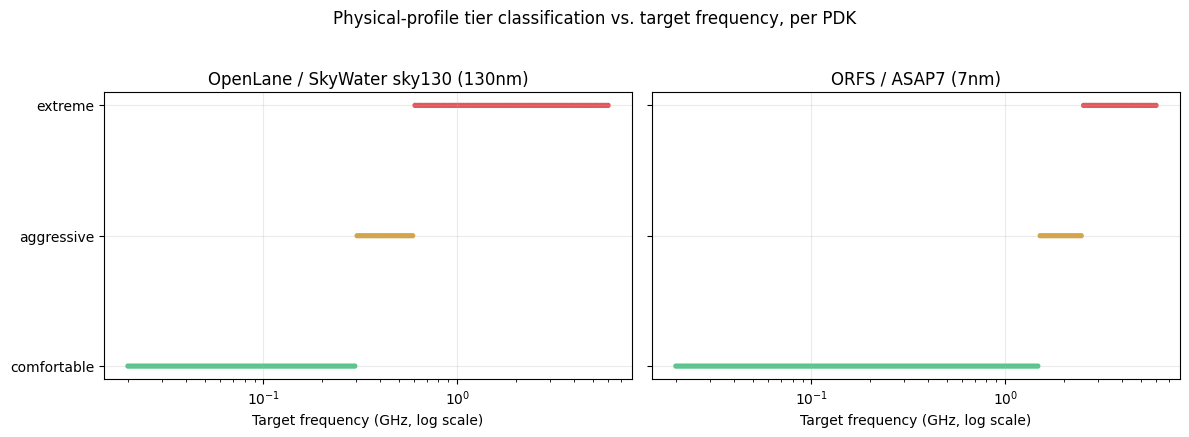


What actually changes at each tier transition (OpenLane, 5.0 GHz example):
 - [PHYSICAL PROFILE] 5.000 GHz classified as 'extreme' for OpenLane/sky130-class flow -- switched SYNTH_STRATEGY to 'DELAY 1' and enabled resizer timing/design optimizations (were area-optimized/off by default, which fights a tight clock target).
 - [PHYSICAL PROFILE WARNING] 5.000 GHz is well past this flow's typical comfortable range (<= 0.3 GHz) for a standard-cell design with no custom pipelining. Even with aggressive synthesis + resizer settings, expect real setup-timing violations without design-level pipelining. This is a rule-of-thumb guardrail, not a guarantee either way -- treat it as 'budget time for STA debugging', not 'this will definitely fail'.


In [3]:
freqs_ghz = np.logspace(np.log10(0.02), np.log10(6.0), 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
tier_rank = {"comfortable": 0, "aggressive": 1, "extreme": 2}
tier_colors = {"comfortable": "#52c98a", "aggressive": "#d9a441", "extreme": "#e0575c"}

for ax, engine, title in zip(
    axes, ("openlane", "orfs"),
    ("OpenLane / SkyWater sky130 (130nm)", "ORFS / ASAP7 (7nm)")
):
    tiers = [physical_profile.classify(engine, f) for f in freqs_ghz]
    ranks = [tier_rank[t] for t in tiers]
    colors = [tier_colors[t] for t in tiers]
    ax.scatter(freqs_ghz, ranks, c=colors, s=8)
    ax.set_xscale("log")
    ax.set_xlabel("Target frequency (GHz, log scale)")
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["comfortable", "aggressive", "extreme"])
    ax.set_title(title)
    ax.grid(alpha=0.25)

fig.suptitle("Physical-profile tier classification vs. target frequency, per PDK", y=1.03)
plt.tight_layout()
plt.savefig("figures_tier_sweep.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nWhat actually changes at each tier transition (OpenLane, 5.0 GHz example):")
params, notes = physical_profile.apply({}, "openlane", 5.0)
for n in notes:
    print(" -", n)


## Part 3 — Self-healing: diagnosing a real failure class

Wakeel's differentiator over a plain parameter-search tool (like OpenROAD's own [AutoTuner](https://openroad-flow-scripts.readthedocs.io/en/latest/user/InstructionsForAutoTuner.html), which searches a PPA objective blind) is that its knowledge base reads *why* a flow step failed — from real signoff report content, not just an exit code — and proposes a diagnosed, explained fix grounded in the actual parameter schema.

The example below is drawn from a real bug this project hit and fixed: a knowledge-base rule (`LVS-003`) is meant to disable two resizer-optimization flags to resolve a specific class of LVS mismatch. Early on, that rule's fix was written in JSON as `0`/`1` instead of `true`/`false` — a completely reasonable thing for a human editing JSON to write — which silently became a numeric *delta* instead of a boolean *set* (`True + 0 = 1`, a no-op that still logged as "success"). The engine now resolves the adjustment's type from the schema itself, not the JSON literal's Python type, so this class of bug can't recur. The cell below shows the fix actually working against the real rule and the real schema.


In [4]:
failure_log = (
    "ERROR: LVS fails after enabling optimizations -- extra logic cells "
    "in wrapper LVS mismatch detected during signoff."
)

matches = kb.match(failure_log, top_n=1)
assert matches, "expected a confident match"
m = matches[0]
print(f"Matched rule: {m.rule['id']}  (confidence score: {m.score:.2f})")
print(f"Category: {m.rule.get('category')}")
print(f"Matched keywords: {m.matched_keywords}\n")

# Simulate the flags being ON going into this failure (as a real run would have them)
params_before = {"PL_RESIZER_DESIGN_OPTIMIZATIONS": True, "GLB_RESIZER_DESIGN_OPTIMIZATIONS": True}
print("Before:", params_before)

params_after, explanation, touched_keys = kb.apply(m, dict(params_before), "openlane")
print("After: ", {k: params_after[k] for k in params_before})
print(f"\nKeys the fix touched: {touched_keys}")
print(f"\nExplanation surfaced to the user:\n{explanation}")


Matched rule: LVS-003  (confidence score: 0.67)
Category: LVS Mismatches
Matched keywords: ['LVS fails after enabling optimizations', 'logic cells in wrapper LVS mismatch']

Before: {'PL_RESIZER_DESIGN_OPTIMIZATIONS': True, 'GLB_RESIZER_DESIGN_OPTIMIZATIONS': True}
After:  {'PL_RESIZER_DESIGN_OPTIMIZATIONS': False, 'GLB_RESIZER_DESIGN_OPTIMIZATIONS': False}

Keys the fix touched: {'PL_RESIZER_DESIGN_OPTIMIZATIONS', 'GLB_RESIZER_DESIGN_OPTIMIZATIONS'}

Explanation surfaced to the user:
At the top-level wrapper, resizer optimizations can add unexpected cells that break LVS. Disable design optimizations at the wrapper level; individual hardened macros should already be optimized.
Applied: PL_RESIZER_DESIGN_OPTIMIZATIONS: True -> False (forced); GLB_RESIZER_DESIGN_OPTIMIZATIONS: True -> False (forced)


**Confidence floor — a weak match is rejected, not trusted anyway.** A single coincidental keyword overlap shouldn't get treated with the same authority as a clean multi-keyword hit. Below, a log sharing only 1 of 5 required keywords with a (synthetic, deliberately strict) rule is correctly rejected rather than silently "matched."


In [5]:
strict_rule_kb_path = "_demo_strict_rule.json"
with open(strict_rule_kb_path, "w") as f:
    json.dump({"rules": [{
        "id": "DEMO-001",
        "category": "demo",
        "error_keywords": ["alpha", "beta", "gamma", "delta", "epsilon"],
        "adjustments": {},
        "explanation": "Needs several simultaneous symptoms to be a confident diagnosis.",
    }]}, f)

demo_kb = KnowledgeBase(schema, path=strict_rule_kb_path)
weak_log = "the build mentioned alpha somewhere in a comment"
result = demo_kb.match(weak_log, top_n=1)
print(f"MIN_MATCH_SCORE threshold: {KnowledgeBase.MIN_MATCH_SCORE}")
print(f"Result for a 1-of-5-keyword match: {result}  <- correctly empty, not a false-confidence diagnosis")

os.remove(strict_rule_kb_path)


MIN_MATCH_SCORE threshold: 0.34
Result for a 1-of-5-keyword match: []  <- correctly empty, not a false-confidence diagnosis


## Part 4 — Real hardware run (OpenLane / sky130)

Everything above runs anywhere, including a hosted notebook environment, because it's pure configuration/decision logic with no Docker or PDK dependency. Actually *executing* an OpenLane or ORFS flow needs a real Docker install and a real PDK (`sky130A` / ASAP7), which a hosted Colab session doesn't provide — this matches the submission FAQ's guidance to run the layout-generation flow locally and include the resulting output/images here with explanation, rather than executing it live in-notebook.

The cell below loads a real sweep-benchmark CSV that Wakeel's orchestrator writes after an actual run (`ppa_reports/<design>_Sweep_Benchmark.csv`) if one has been placed alongside this notebook, and plots real PPA-vs-frequency results. If none is present yet, it prints exactly how to generate one.


,Target_Period(ps),Freq(GHz),Area(um2),Power(W),Mode,Status
0,5000,0.2,86.0,0.000021,synth_power_only,SUCCESS
1,2000,0.5,86.0,0.000053,synth_power_only,SUCCESS
2,1000,1.0,86.0,0.000106,synth_power_only,SUCCESS
3,667,1.5,86.0,0.000159,synth_power_only,SUCCESS
4,500,2.0,86.0,0.000212,synth_power_only,SUCCESS


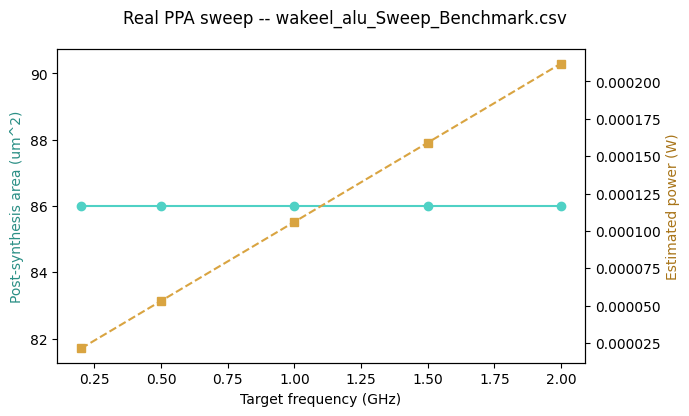

In [6]:
import glob

csv_candidates = glob.glob("ppa_reports/*.csv")

if csv_candidates:
    df = pd.read_csv(csv_candidates[0])
    display(df)

    df_ok = df[df["Status"] == "SUCCESS"].copy()
    if not df_ok.empty:
        fig, ax1 = plt.subplots(figsize=(7, 4.2))
        ax2 = ax1.twinx()
        ax1.plot(df_ok["Freq(GHz)"], df_ok["Area(um2)"], "o-", color="#4fd1c5", label="Area (um^2)")
        ax2.plot(df_ok["Freq(GHz)"], df_ok["Power(W)"], "s--", color="#d9a441", label="Power (W)")
        ax1.set_xlabel("Target frequency (GHz)")
        ax1.set_ylabel("Post-synthesis area (um^2)", color="#2a8f85")
        ax2.set_ylabel("Estimated power (W)", color="#a87418")
        fig.suptitle(f"Real PPA sweep -- {os.path.basename(csv_candidates[0])}")
        fig.tight_layout()
        plt.savefig("figures_real_ppa_sweep.png", dpi=130, bbox_inches="tight")
        plt.show()
else:
    print("No real sweep-benchmark CSV found next to this notebook yet.\n")
    print("To generate one on a machine with Docker + the sky130/ASAP7 PDK installed:\n")
    print('  python3 cli_run.py "run <design_name> at 500 MHz on 7nm" --sweep 0.2,0.5,1.0,2.0\n')
    print("Wakeel writes the results to ppa_reports/<top_module>_Sweep_Benchmark.csv automatically --")
    print("copy that file into this notebook's folder and re-run this cell.")


*(This section intentionally does not include fabricated numbers — only real output from an actual local run belongs here. See the Reproducibility section below for exactly how those numbers get generated.)*


## Reproducibility

**Parts 1–3 (config generation, physical profiling, self-healing) — runs anywhere, including this notebook as submitted, including Google Colab:**
- The Setup cell clones the real project and checks out a fixed commit (`edeeab4147ab054a189be4a18b63aea70369424b`) — not `main` — so results stay reproducible even as the project keeps being developed after this submission.
- Only `matplotlib`, `numpy`, `pandas` beyond the standard library (all pre-installed in Colab); the `wakeel` package itself needs nothing else to import.

**Part 4 (real OpenLane/ORFS hardware run) — needs a local machine, not Colab:**
1. Install Docker and either [OpenLane](https://openlane.readthedocs.io/en/latest/getting_started/index.html) (sky130) or [OpenROAD-flow-scripts](https://openroad-flow-scripts.readthedocs.io/) (ASAP7).
2. Inside the same `wakeel_repo_checkout/` folder this notebook clones: `pip install -r requirements-dev.txt`
3. Run a real sweep, e.g.: `python3 cli_run.py "run wakeel_alu at 500 MHz on 7nm" --sweep 0.2,0.5,1.0,2.0`
4. Copy the entire generated `ppa_reports/` folder (containing the `.csv`) so it sits next to the `.ipynb` file (i.e. `ppa_reports/<design>_Sweep_Benchmark.csv` at the same level as this notebook, not flattened and not inside `wakeel_repo_checkout/`), then re-run the Part 4 cell -- it globs `ppa_reports/*.csv`, so the subfolder name and nesting matter.

The full project also includes: a live web dashboard (`index.html` + `wakeel_api.py`) with real-time flow streaming, a Stop/cancel control, an engine/tech-node toggle, and a day/night theme; a 46-test automated test suite (`tests/`, run via `pytest`); and CI (`.github/workflows/tests.yml`) — all passing at the pinned commit above. None of that is needed to run *this notebook*, but it's the system this notebook's logic is drawn from, not a simplified reimplementation for the submission.


## Conclusion

The three pieces demonstrated here — schema-driven configuration, frequency-aware physical profiling, and a self-healing knowledge base that diagnoses real failures instead of only searching a parameter space blind — are aimed at a specific accessibility problem: a lot of what makes RTL-to-GDSII flows usable well is tacit knowledge that currently lives in individual engineers' heads. Making that knowledge executable, inspectable, and testable (see the 46-test suite in the full project) is a small step toward the kind of "reproducible expertise" that lowers the barrier to serious open-source chip design — which is the goal I understand this program to be funding in the first place.

**Project repository:** https://github.com/Rishikesavan0129/wakeel
**License:** Apache License 2.0 (`LICENSE` in this folder)
